In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import least_squares
from scipy.stats import norm
import os

In [2]:
# Read only the column names (first row)
data2023 = pd.read_csv(fr"atusact-2023/atusact_2023.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2023 = pd.read_csv(fr"atusresp-2023/atusresp_2023.dat", dtype={'TUCASEID': str})
jointed_data2023 = pd.merge(data2023, respondents2023, on='TUCASEID', how='inner')
data2024 = pd.read_csv(fr"atusact-2024/atusact_2024.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2024 = pd.read_csv(fr"atusresp-2024/atusresp_2024.dat", dtype={'TUCASEID': str})
joined_data2024 = pd.merge(data2024, respondents2024, on='TUCASEID', how='inner')
joined_data = pd.concat([jointed_data2023, joined_data2024], ignore_index=True)

keep_cols = [
    'TUCASEID',
    'TUDIARYDAY',   # day of week (1=Sun, 2=Mon, ..., 7=Sat) — needed for daytype
    'TUFINLWGT',    # final person weight — use for nationally representative estimates
    'TESCHENR',
    'TESCHFT',
    'TESCHLVL',
    'TRHHCHILD',
    'TRDPFTPT',
    'TELFS',
    'TRTHH',
    'TRCODE',
    'TUACTDUR',   
    'TUSTARTTIM',
    'TUSTOPTIME',
    'TEWHERE',
]
joined_data = joined_data[[c for c in keep_cols if c in joined_data.columns]]

In [3]:
# TUDIARYDAY: 1=Sun, 2=Mon, 3=Tue, 4=Wed, 5=Thu, 6=Fri, 7=Sat
joined_data['daytype'] = joined_data['TUDIARYDAY'].map(
    lambda d: 'weekend' if d in (1, 7) else 'weekday'
)

## Employed - Fulltime - Away

In [4]:
# filter employed
employed = joined_data[joined_data['TELFS'] == 1]
full_time_employed = employed[employed['TRDPFTPT'] == 1]

In [5]:
# ── Step 2: Map activities to occupancy states ────────────────────────────────
# TEWHERE: 1 = respondent's home, anything else = away
# TRCODE prefix '0101' = sleeping (01 personal care → 0101 sleeping)
# States: 'home', 'sleep', 'away'

def map_state(row):
    if str(row['TRCODE']).startswith('0101'):
        return 'sleep'
    elif row['TEWHERE'] == 1:
        return 'home'
    else:
        return 'away'

df = full_time_employed.copy()
df['state'] = df.apply(map_state, axis=1)

# ── Diagnostic: work activity (05xxxx) reported at home ──────────────────────
work_at_home = df[df['TRCODE'].str.startswith('05') & (df['TEWHERE'] == 1)]
total_work    = df[df['TRCODE'].str.startswith('05')]
pct = 100 * len(work_at_home) / len(total_work) if len(total_work) > 0 else 0
print(f"Work activities (05xxxx) at home: {len(work_at_home):,} / {len(total_work):,} ({pct:.1f}%)")



Work activities (05xxxx) at home: 3,353 / 10,185 (32.9%)


In [6]:
# ── Work location type: day-level attribute (weekdays only) ───────────────────
# For each (person, diary day), classify that day's work pattern:
#   wfh    : all work episodes that day were at home
#   office : all work episodes that day were away from home
#   hybrid : mixed home and away work on the same day
#   no_work: no work episodes recorded that day
# This is a day-level attribute, not a permanent persona trait.

work_eps = df[(df['TRCODE'].str.startswith('05'))].copy()

day_work = (
    work_eps.groupby(['TUCASEID', 'TUDIARYDAY'])
    .agg(
        total_work_eps   = ('TEWHERE', 'count'),
        work_at_home_eps = ('TEWHERE', lambda x: (x == 1).sum()),
    )
    .reset_index()
)
day_work['pct_home'] = day_work['work_at_home_eps'] / day_work['total_work_eps']

def classify_day_work(pct):
    if pct == 1.0:
        return 'wfh'
    elif pct == 0.0:
        return 'office'
    else:
        return 'hybrid'

day_work['work_location'] = day_work['pct_home'].apply(classify_day_work)

# Merge back onto all weekday rows; days with no work episodes → 'no_work'
df = df.merge(day_work[['TUCASEID', 'TUDIARYDAY', 'work_location']], on=['TUCASEID', 'TUDIARYDAY'], how='left')
df['work_location'] = df['work_location'].fillna('no_work')

print(df.loc[df['daytype'] == 'weekday', 'work_location'].value_counts())
print(df.loc[df['daytype'] == 'weekday', 'work_location'].value_counts(normalize=True).mul(100).round(1))

work_location
office     37018
wfh        13741
hybrid      8413
no_work     7590
Name: count, dtype: int64
work_location
office     55.4
wfh        20.6
hybrid     12.6
no_work    11.4
Name: proportion, dtype: float64


In [7]:
# Weekday: full-time employed whose diary day was an office (away) day
# Weekend: all full-time employed (df already filtered to full_time_employed)
df = df[
    ((df['daytype'] == 'weekday') & (df['work_location'] == 'office')) |
    (df['daytype'] == 'weekend')
].reset_index(drop=True)

print(f"Weekday (office): {df[df['daytype']=='weekday']['TUCASEID'].nunique():,} respondents")
print(f"Weekend:          {df[df['daytype']=='weekend']['TUCASEID'].nunique():,} respondents")

# Parse TUSTARTTIM ("HH:MM:SS") → minutes since midnight
df['t_start_min'] = pd.to_timedelta(df['TUSTARTTIM']).dt.total_seconds() / 60

# ATUS diary starts at 4:00am — shift so t=0 is 4am (bin 0 = first 15-min slot)
DIARY_START_MIN = 4 * 60   # 240 minutes
df['t_entry'] = (df['t_start_min'] - DIARY_START_MIN) % (24 * 60)

df = df.sort_values(['TUCASEID', 'TUDIARYDAY', 't_entry']).reset_index(drop=True)
df['t_exit'] = (df['t_entry'] + df['TUACTDUR']) % (24 * 60)


Weekday (office): 2,114 respondents
Weekend:          3,461 respondents


In [8]:
# ── Filter out night/early shift workers ─────────────────────────────────────
# Compute fraction of work duration outside normal hours (before 7am or after 6pm)
# Flag as shift worker if majority (>50%) of work time is outside normal hours

EARLY_CUTOFF = (8 - 4) * 60   # 8am  = 240 min since 4am
NIGHT_CUTOFF = (18 - 4) * 60  # 6pm  = 840 min since 4am

work_eps = df[(df['TRCODE'].str.startswith('05')) & (df['daytype'] == 'weekday')].copy()

work_time = (
    work_eps.groupby('TUCASEID')
    .apply(lambda g: pd.Series({
        'total_work_min':   g['TUACTDUR'].sum(),
        'offhour_work_min': g.loc[(g['t_entry'] <= EARLY_CUTOFF) | (g['t_entry'] >= NIGHT_CUTOFF), 'TUACTDUR'].sum(),
    }))
    .reset_index()
)
work_time['offhour_frac'] = work_time['offhour_work_min'] / work_time['total_work_min']

night_shift_ids = set(work_time.loc[work_time['offhour_frac'] > 0.6, 'TUCASEID'])
print(f"Night/early shift workers identified: {len(night_shift_ids):,}")

df = df[~df['TUCASEID'].isin(night_shift_ids)].reset_index(drop=True)
print(f"Remaining respondents: {df['TUCASEID'].nunique():,}")

Night/early shift workers identified: 637
Remaining respondents: 4,938


/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_98780/382643090.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [9]:
# ── Step 3: π_0 — initial state distribution (weighted) ──────────────────────
# First activity per (respondent, diary day) = state at t=0 (4am)

first_acts = df.groupby(['TUCASEID', 'TUDIARYDAY', 'daytype']).first().reset_index()

def compute_pi0(first_acts_df):
    counts = first_acts_df.groupby('state')['TUFINLWGT'].sum().rename('weight_sum').reset_index()
    counts['prob'] = counts['weight_sum'] / counts['weight_sum'].sum()
    return counts

pi0_weekday = compute_pi0(first_acts[first_acts['daytype'] == 'weekday'])
pi0_weekend = compute_pi0(first_acts[first_acts['daytype'] == 'weekend'])

print("── Weekday π_0 ──")
print(pi0_weekday)
print("\n── Weekend π_0 ──")
print(pi0_weekend)


── Weekday π_0 ──
   state    weight_sum      prob
0   away  1.580626e+09  0.054842
1   home  4.610326e+08  0.015996
2  sleep  2.677964e+10  0.929161

── Weekend π_0 ──
   state    weight_sum      prob
0   away  1.151741e+09  0.042622
1   home  7.983804e+08  0.029545
2  sleep  2.507210e+10  0.927833


In [10]:


# Combine weekday and weekend π_0 into one DataFrame
pi0_combined = pd.concat([
    pi0_weekday.assign(daytype='weekday'),
    pi0_weekend.assign(daytype='weekend'),
])[['daytype', 'state', 'prob']].reset_index(drop=True)
pi0_combined = pi0_combined.rename(columns={'prob': 'fulltime_daily_worker'})

SAVE_PATH = '../data/occupancy_probability/initial_probability.csv'
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

if os.path.exists(SAVE_PATH):
    existing = pd.read_csv(SAVE_PATH)
    if 'fulltime_daily_worker' not in existing.columns:
        existing = existing.merge(pi0_combined[['daytype', 'state', 'fulltime_daily_worker']],
                                  on=['daytype', 'state'], how='left')
        print("Column 'fulltime_daily_worker' added to existing file.")
    else:
        print("Column 'fulltime_daily_worker' already exists — skipping.")
    existing.to_csv(SAVE_PATH, index=False)
else:
    pi0_combined.to_csv(SAVE_PATH, index=False)
    print(f"Created new file: {SAVE_PATH}")

print(pi0_combined)

Column 'fulltime_daily_worker' already exists — skipping.
   daytype  state  fulltime_daily_worker
0  weekday   away               0.054842
1  weekday   home               0.015996
2  weekday  sleep               0.929161
3  weekend   away               0.042622
4  weekend   home               0.029545
5  weekend  sleep               0.927833


In [82]:
from scipy.stats import expon
from scipy.optimize import minimize
from scipy.special import logsumexp

BIN_MIN = 15

# ── Sojourn construction (unchanged) ─────────────────────────────────────────
df_s = df.sort_values(['TUCASEID', 'TUDIARYDAY', 't_entry']).copy()
df_s['state_prev'] = df_s.groupby(['TUCASEID', 'TUDIARYDAY'])['state'].shift(1)
df_s['new_sojourn'] = (df_s['state'] != df_s['state_prev']).astype(int)
df_s['sojourn_id']  = df_s.groupby(['TUCASEID', 'TUDIARYDAY'])['new_sojourn'].cumsum()

sojourns = (
    df_s.groupby(['TUCASEID', 'TUDIARYDAY', 'daytype', 'state', 'sojourn_id', 'TUFINLWGT'])
        .agg(t_entry=('t_entry', 'first'), duration_min=('TUACTDUR', 'sum'))
        .reset_index()
)
sojourns['t_entry_bin'] = (sojourns['t_entry'] // BIN_MIN).astype(int)
sojourns['log_duration'] = np.log(sojourns['duration_min'].clip(lower=1))

# ── Per-state fitting functions ───────────────────────────────────────────────

def fit_sleep(g):
    """Normal fit on log(duration) — equivalent to log-normal, no truncation needed."""
    w  = g['TUFINLWGT'].values
    ld = g['log_duration'].values
    mu  = np.average(ld, weights=w)
    sig = np.sqrt(np.average((ld - mu)**2, weights=w))
    return pd.Series({'count': len(g), 'mu_log': mu, 'sigma_log': sig})


def fit_home(g):
    """Log-normal fitted on KDE-smoothed samples to bypass heaping."""
    x = g['duration_min'].values.astype(float)
    w = g['TUFINLWGT'].values.astype(float)
    w = w / w.sum()
    n = len(g)

    # Fall back to direct weighted log-normal for sparse bins
    log_x = np.log(x.clip(min=0.5))
    if n < 20:
        mu  = np.average(log_x, weights=w)
        sig = np.sqrt(np.average((log_x - mu)**2, weights=w))
        return pd.Series({'count': n, 'mu_log': mu, 'sigma_log': max(sig, 0.05)})

    # KDE on log scale → resample → fit log-normal
    try:
        kde       = gaussian_kde(log_x, weights=w, bw_method=0.15)
        log_samp  = kde.resample(3000, seed=0).flatten()
        log_samp  = log_samp[(log_samp > np.log(0.5)) & (log_samp < np.log(1440))]

        mu  = log_samp.mean()
        sig = log_samp.std()
    except Exception:
        mu  = np.average(log_x, weights=w)
        sig = np.sqrt(np.average((log_x - mu)**2, weights=w))

    return pd.Series({'count': n, 'mu_log': mu, 'sigma_log': max(sig, 0.05)})


def fit_away(g):
    """
    2-component log-normal mixture fitted by EM.
    Returns: w1, mu1, sig1, mu2, sig2
    Component 1 ≈ short trips (~30 min), Component 2 ≈ long trips (~5 h).
    """
    ld = g['log_duration'].values.astype(float)
    sw = g['TUFINLWGT'].values.astype(float)
    sw = sw / sw.sum()
    n  = len(ld)

    if n < 10:                          # too few obs — fall back to log-normal
        mu  = np.average(ld, weights=sw)
        sig = np.sqrt(np.average((ld - mu)**2, weights=sw))
        return pd.Series({'count': n,
                          'w1': 1.0, 'mu1': mu, 'sig1': sig,
                          'w2': 0.0, 'mu2': mu, 'sig2': sig})

    # ── EM initialisation: split at log(120 min) ─────────────────────────────
    split  = np.log(120)
    mask1  = ld < split
    w1     = sw[mask1].sum()  if mask1.any()  else 0.4
    w2     = sw[~mask1].sum() if (~mask1).any() else 0.6

    mu1  = np.average(ld[mask1],  weights=sw[mask1])  if mask1.any()  else np.log(30)
    mu2  = np.average(ld[~mask1], weights=sw[~mask1]) if (~mask1).any() else np.log(300)
    sig1 = max(np.sqrt(np.average((ld[mask1]  - mu1)**2, weights=sw[mask1]))  if mask1.any()  else 0.8, 0.1)
    sig2 = max(np.sqrt(np.average((ld[~mask1] - mu2)**2, weights=sw[~mask1])) if (~mask1).any() else 0.8, 0.1)

    # ── EM iterations ────────────────────────────────────────────────────────
    for _ in range(40):
        # E-step: responsibilities
        log_r1 = np.log(w1 + 1e-12) - 0.5*((ld-mu1)/sig1)**2 - np.log(sig1)
        log_r2 = np.log(w2 + 1e-12) - 0.5*((ld-mu2)/sig2)**2 - np.log(sig2)
        log_Z  = np.logaddexp(log_r1, log_r2)
        r1 = np.exp(log_r1 - log_Z)      # shape (n,)
        r2 = 1.0 - r1

        # Incorporate sample weights
        rw1, rw2 = r1 * sw, r2 * sw

        # M-step
        w1  = rw1.sum();  w2  = rw2.sum()
        mu1 = np.dot(rw1, ld) / (w1 + 1e-12)
        mu2 = np.dot(rw2, ld) / (w2 + 1e-12)
        sig1 = max(np.sqrt(np.dot(rw1, (ld-mu1)**2) / (w1 + 1e-12)), 0.05)
        sig2 = max(np.sqrt(np.dot(rw2, (ld-mu2)**2) / (w2 + 1e-12)), 0.05)
        w1, w2 = w1 / (w1+w2), w2 / (w1+w2)   # renormalise

    # Convention: component 1 always has the smaller mean
    if mu1 > mu2:
        w1, w2   = w2, w1
        mu1, mu2 = mu2, mu1
        sig1, sig2 = sig2, sig1

    return pd.Series({'count': n,
                      'w1': w1, 'mu1': mu1, 'sig1': sig1,
                      'w2': w2, 'mu2': mu2, 'sig2': sig2})


# ── Apply per state ───────────────────────────────────────────────────────────
FIT_FN = {'sleep': fit_sleep, 'home': fit_home, 'away': fit_away}

sojourn_stats = {}
for state, fn in FIT_FN.items():
    sub = sojourns[sojourns['state'] == state]
    stats = (sub.groupby(['daytype', 't_entry_bin'])
                .apply(fn)
                .reset_index())
    stats['state'] = state
    sojourn_stats[state] = stats

sojourn_stats = pd.concat(sojourn_stats.values(), ignore_index=True)

/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_98780/4217117838.py:128: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fn)
/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_98780/4217117838.py:128: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fn)
/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_98780/4217117838.py:128: FutureWarning: DataFrameGroupBy.apply operated on the 

In [86]:
SMOOTH_SIGMA = {
    'sleep': 0.4,
    'home':  0.9,
    'away':  1.2,
}
SMOOTH_COLS = {
    'sleep': ['mu_log', 'sigma_log'],
    'home':  ['mu_log', 'sigma_log'],
    'away':  ['w1', 'mu1', 'sig1', 'mu2', 'sig2'],
}

def smooth_params(df, cols, sigma):
    df = df.sort_values('t_entry_bin').copy()
    for col in cols:
        df[col] = gaussian_filter1d(df[col].values.astype(float), sigma=sigma)
    return df

sojourn_stats_smooth = {}
for state in states:
    sub = sojourn_stats[
        (sojourn_stats['state'] == state) &
        (sojourn_stats['daytype'] == DAYTYPE)
    ].copy()

    sub = smooth_params(sub, SMOOTH_COLS[state], sigma=SMOOTH_SIGMA[state])

    # ── Clip smoothed params to original range to prevent extrapolation ───
    orig = sojourn_stats[
        (sojourn_stats['state'] == state) &
        (sojourn_stats['daytype'] == DAYTYPE)
    ]
    for col in SMOOTH_COLS[state]:
        lo = orig[col].quantile(0.05)
        hi = orig[col].quantile(0.95)
        sub[col] = sub[col].clip(lo, hi)

    # ── Hard validity clips ───────────────────────────────────────────────
    if state == 'sleep':
        sub['sigma_log'] = sub['sigma_log'].clip(lower=0.05)
    elif state == 'home':
        sub['sigma_log'] = sub['sigma_log'].clip(lower=0.05)  # ← was gamma, now log-normal
    elif state == 'away':
        sub['w1']   = sub['w1'].clip(0.01, 0.99)
        sub['sig1'] = sub['sig1'].clip(lower=0.05)
        sub['sig2'] = sub['sig2'].clip(lower=0.05)
        sub['mu1']  = sub[['mu1', 'mu2']].min(axis=1)
        sub['mu2']  = sub[['mu1', 'mu2']].max(axis=1)

    sojourn_stats_smooth[state] = sub

sojourn_stats_smooth = pd.concat(sojourn_stats_smooth.values(), ignore_index=True)

Set y-limit for sleep to 0–1584 min
Set y-limit for sleep to 0–1584 min
Set y-limit for home to 0–739 min
Set y-limit for home to 0–739 min
Set y-limit for away to 0–1265 min
Set y-limit for away to 0–1265 min


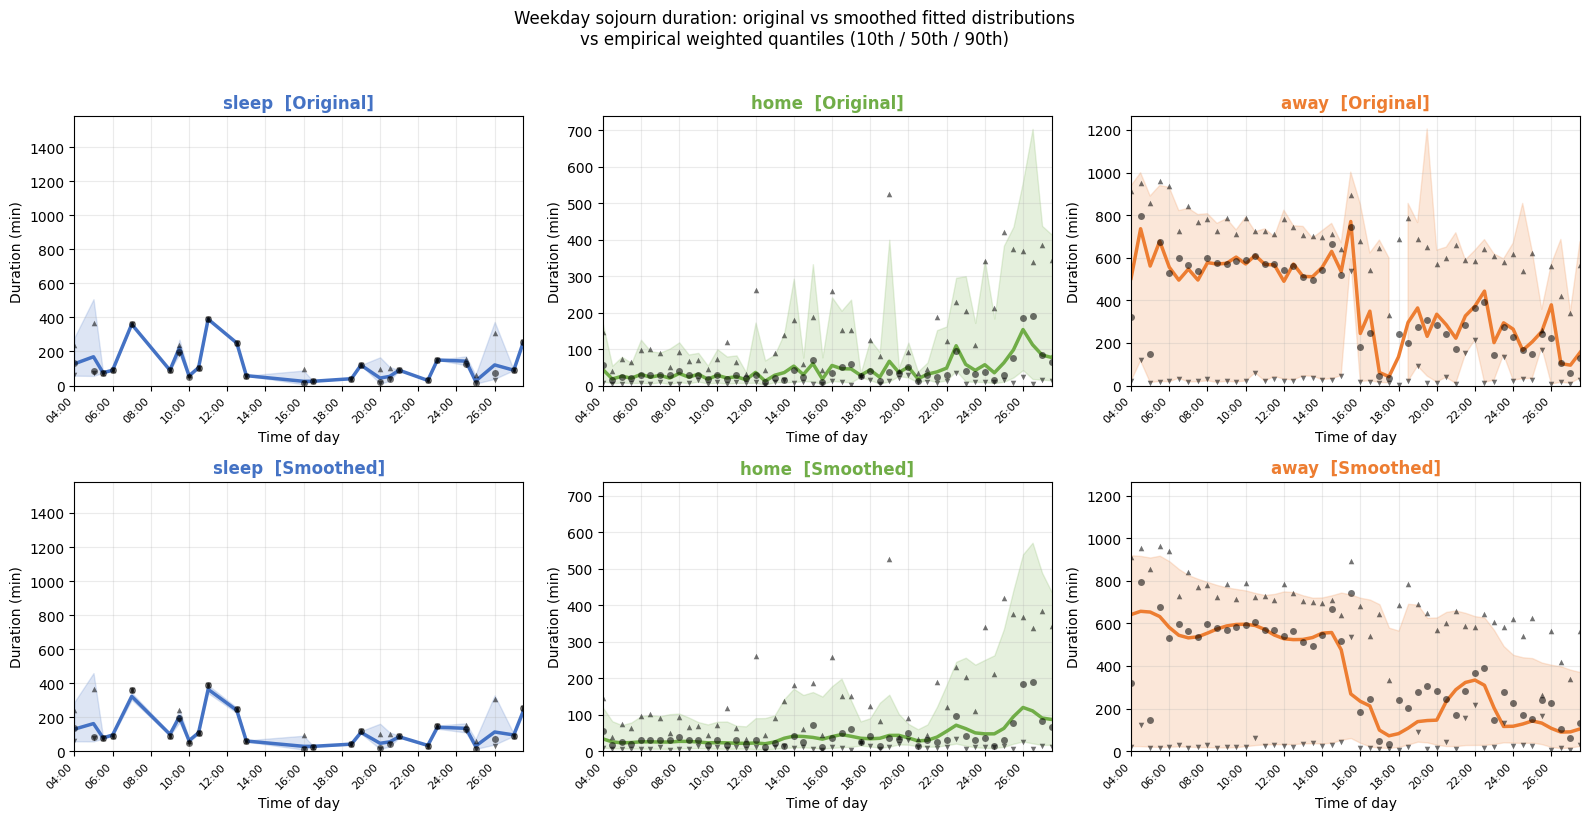

In [88]:
from scipy.stats import lognorm, gamma, norm as _norm

def sleep_q(mu, sig, q):
    return np.exp(mu + _norm.ppf(q) * sig)

def home_q(mu, sig, q):
    return np.exp(mu + _norm.ppf(q) * sig)

def away_q(w1, mu1, sig1, mu2, sig2, q):
    from scipy.optimize import brentq
    w2 = 1 - w1
    def cdf(x):
        return (w1 * lognorm.cdf(x, s=sig1, scale=np.exp(mu1)) +
                w2 * lognorm.cdf(x, s=sig2, scale=np.exp(mu2)))
    try:
        return brentq(lambda x: cdf(x) - q, 1, 1440)
    except ValueError:
        return np.nan

def compute_quantiles(fit, state):
    q10, q50, q90 = [], [], []
    for _, row in fit.iterrows():
        if state == 'sleep':
            qs = [sleep_q(row['mu_log'], row['sigma_log'], q) for q in PCTS]
        elif state == 'home':
            qs = [home_q(row['mu_log'], row['sigma_log'], q) for q in PCTS]
        else:
            qs = [away_q(row['w1'], row['mu1'], row['sig1'],
                         row['mu2'], row['sig2'], q) for q in PCTS]
        q10.append(qs[0]); q50.append(qs[1]); q90.append(qs[2])
    return np.array(q10), np.array(q50), np.array(q90)

# ── 2-row plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)

VERSIONS = [
    (sojourn_stats,        axes[0], 'Original'),
    (sojourn_stats_smooth, axes[1], 'Smoothed'),
]

for stats_df, row_axes, version_label in VERSIONS:
    for ax, state in zip(row_axes, states):
        color = STATE_COLORS[state]
        fit  = (stats_df[(stats_df['state'] == state) &
                         (stats_df['daytype'] == DAYTYPE)]
                .sort_values('t_entry_bin'))
        bins = fit['t_entry_bin'].values

        q10, q50, q90 = compute_quantiles(fit, state)
        ax.fill_between(bins, q10, q90, alpha=0.18, color=color, label='fitted 10–90%')
        ax.plot(bins, q50, lw=2.5, color=color, label='fitted median')

        bins_emp = sorted(b for (st, b) in emp_q if st == state)
        for q, marker, ms in [(0.10, 'v', 4), (0.50, 'o', 5), (0.90, '^', 4)]:
            vals_emp = [emp_q[(state, b)][q] for b in bins_emp]
            ax.scatter(bins_emp, vals_emp, s=ms**2, color='k', alpha=0.55,
                       marker=marker, linewidths=0, label=f'actual {int(q*100)}th', zorder=3)

        ax.set_title(f'{state}  [{version_label}]', fontsize=12,
                     fontweight='bold', color=color)
        ax.set_xlabel('Time of day')
        ax.set_ylabel('Duration (min)')
        ax.set_xlim(0, 47)
        ax.set_xticks(tick_bins)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
        #ax.legend(fontsize=7, ncol=2)
        ax.grid(True, alpha=0.25)

# ── Match y-limits column by column (same state = same column) ───────────────
for col in range(3):
    ymax = max(axes[row][col].get_ylim()[1] for row in range(2))
    for row in range(2):
        axes[row][col].set_ylim(bottom=0, top=ymax)
        print(f"Set y-limit for {states[col]} to 0–{ymax:.0f} min")

fig.suptitle('Weekday sojourn duration: original vs smoothed fitted distributions\n'
             'vs empirical weighted quantiles (10th / 50th / 90th)', y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# ── Step 5: P — transition probability matrix ────────────────────────────────
# Transitions between merged state sojourns (not raw activities)

sojourns_s = sojourns.sort_values(['TUCASEID', 'TUDIARYDAY', 't_entry']).copy()
sojourns_s['t_exit'] = sojourns_s['t_entry'] + sojourns_s['duration_min']
sojourns_s['t_exit_bin'] = (sojourns_s['t_exit'] // BIN_MIN).astype(int)
sojourns_s['state_next'] = sojourns_s.groupby(['TUCASEID', 'TUDIARYDAY'])['state'].shift(-1)

transitions = sojourns_s.dropna(subset=['state_next'])

trans_counts = (
    transitions.groupby(['daytype', 'state', 't_exit_bin', 'state_next'])['TUFINLWGT']
    .sum()
    .rename('weight_sum')
    .reset_index()
)
trans_prob = trans_counts.copy()
trans_prob['prob'] = trans_counts['weight_sum'] / trans_counts.groupby(
    ['daytype', 'state', 't_exit_bin']
)['weight_sum'].transform('sum')


from scipy.ndimage import gaussian_filter1d

def get_smoothed_transitions(trans_counts, trans_marg, sigma=1.0, alpha=5.0):
    """
    sigma: strength of temporal smoothing (Gaussian blur)
    alpha: strength of global prior (higher = more 'average' behavior in sparse bins)
    """
    # 1. Pivot to [bin] x [next_state]
    pivoted = trans_counts.pivot_table(
        index=['daytype', 'state', 't_exit_bin'], 
        columns='state_next', 
        values='weight_sum', 
        fill_value=0
    )
    
    # 2. Apply Gaussian smoothing across the time dimension
    smoothed = pivoted.groupby(['daytype', 'state'], group_keys=False).apply(
        lambda x: x.apply(lambda col: gaussian_filter1d(col, sigma=sigma, mode='wrap'))
    )
    
    # 3. Incorporate Global Prior (Laplace/Bayesian Smoothing)
    # This ensures that even if a bin is empty, we don't have 0 probabilities
    # We add 'alpha' virtual observations distributed according to global averages
    
    def apply_prior(group):
        day_type = group.name[0]
        state_from = group.name[1]
        
        # Get global probabilities for this state
        prior = trans_marg[
            (trans_marg['daytype'] == day_type) & 
            (trans_marg['state'] == state_from)
        ].set_index('state_next')['prob']
        
        # Ensure prior matches the columns of our group
        prior = prior.reindex(group.columns, fill_value=0)
        
        # Blend: (Observed + alpha * Global) / (Total Observed + alpha)
        return (group + alpha * prior) / (group.sum(axis=1).values[:, None] + alpha)

    probs_smooth = smoothed.groupby(['daytype', 'state'], group_keys=False).apply(apply_prior)
    
    return probs_smooth

trans_marg = (
    trans_counts.groupby(['daytype', 'state', 'state_next'])['weight_sum']
    .sum()
    .reset_index()
)
trans_marg['prob'] = trans_marg['weight_sum'] / trans_marg.groupby(
    ['daytype', 'state'])['weight_sum'].transform('sum')

# Generate the final transition matrix
trans_prob_smooth = get_smoothed_transitions(trans_counts, trans_marg)

/var/folders/hc/35sw0p9s6sdg8k4mnjml0b2m0000gn/T/ipykernel_98780/3096835462.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sojourn_marg = sojourn_stats.groupby(['daytype', 'state']).apply(


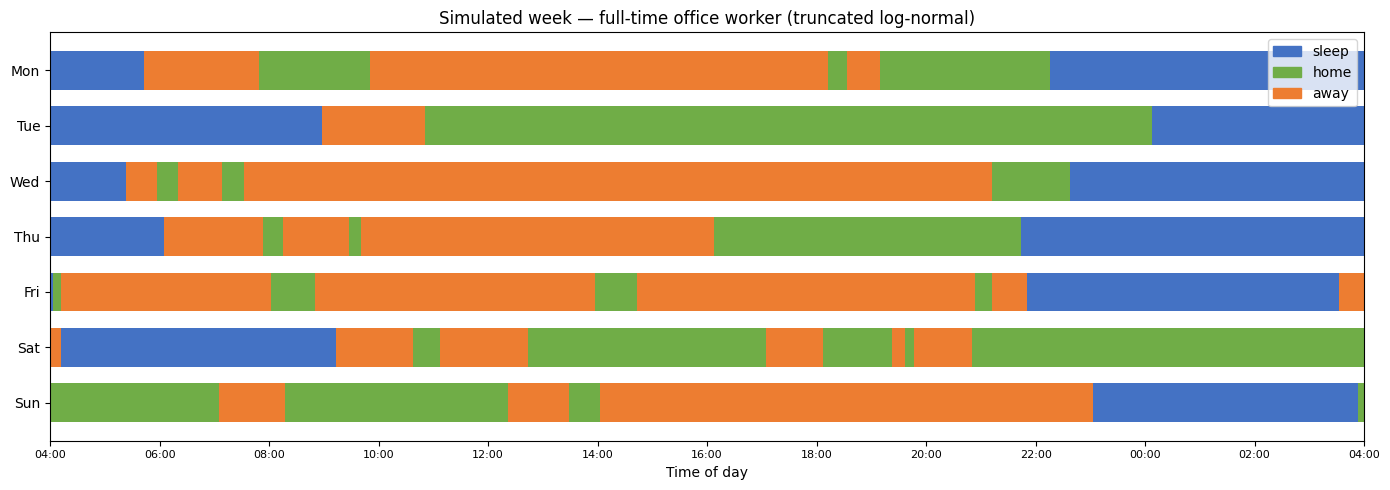

In [14]:

# ── Semi-Markov week simulation ───────────────────────────────────────────────
from scipy.stats import truncnorm

sojourn_lookup = sojourn_stats.set_index(['daytype', 'state', 't_entry_bin'])

sojourn_marg = sojourn_stats.groupby(['daytype', 'state']).apply(
    lambda g: pd.Series({'mu_log': np.average(g['mu_log'], weights=g['count']),
                         'sigma_log': np.average(g['sigma_log'], weights=g['count'])})
).reset_index().set_index(['daytype', 'state'])

DAY_MINUTES = 1440

# Physical upper bounds per state (minutes)
STATE_MAX_DUR = {'sleep': 720, 'away': 840, 'home': 960}

def sample_initial_state(pi0_df):
    return np.random.choice(pi0_df['state'], p=pi0_df['prob'])

def sample_duration(state, t_entry, daytype):
    t_bin = int(t_entry // BIN_MIN) % 48
    key = (daytype, state, t_bin)
    row = sojourn_lookup.loc[key] if key in sojourn_lookup.index else \
          sojourn_marg.loc[(daytype, state)] if (daytype, state) in sojourn_marg.index else None
    if row is None:
        return 60.0

    mu, sig = row['mu_log'], row['sigma_log']

    hi = STATE_MAX_DUR.get(state, 1080) # Default to 18 hours if not specified
    hi = max(hi, 2.0) 

    # 3. Truncated Sampling
    if sig < 1e-6:
        return float(np.clip(np.exp(mu), 1.0, hi))

    log_lo, log_hi = 0.0, np.log(hi)
    a = (log_lo - mu) / sig
    b = (log_hi - mu) / sig

    if b <= a:
        return float(hi)

    log_sample = truncnorm.rvs(a, b, loc=mu, scale=sig)
    return float(np.exp(log_sample))

def sample_next_state(state, t_exit, daytype):
    t_bin = int(t_exit // BIN_MIN) % 48
    try:
        row = trans_prob_smooth.loc[(daytype, state, t_bin)]
        return np.random.choice(row.index, p=row.values)
    except KeyError:
        rows = trans_marg[(trans_marg['daytype'] == daytype) & (trans_marg['state'] == state)]
        return np.random.choice(rows['state_next'], p=rows['prob'])

def simulate_day(daytype, pi0_df, carry_state=None, carry_duration=0):
    schedule = []
    if carry_state is not None:
        t = carry_duration
        schedule.append({'state': carry_state, 't_start': 0, 't_end': carry_duration})
        if t >= DAY_MINUTES:
            return schedule, carry_state, t - DAY_MINUTES
        s = sample_next_state(carry_state, t, daytype)
    else:
        s = sample_initial_state(pi0_df)
        t = 0.0

    while t < DAY_MINUTES:
        d = sample_duration(s, t, daytype)
        schedule.append({'state': s, 't_start': t, 't_end': t + d})
        t += d
        if t < DAY_MINUTES:
            s = sample_next_state(s, t, daytype)

    overflow_state    = schedule[-1]['state']
    overflow_duration = schedule[-1]['t_end'] - DAY_MINUTES
    return schedule, overflow_state, overflow_duration

# Simulate Mon–Sun
np.random.seed(54)
days = [
    ('Mon', 'weekday'), ('Tue', 'weekday'), ('Wed', 'weekday'),
    ('Thu', 'weekday'), ('Fri', 'weekday'),
    ('Sat', 'weekend'), ('Sun', 'weekend'),
]
week_schedule = {}
carry_state, carry_dur = None, 0
for name, daytype in days:
    pi0 = pi0_weekday if daytype == 'weekday' else pi0_weekend
    sched, carry_state, carry_dur = simulate_day(daytype, pi0, carry_state, carry_dur)
    week_schedule[name] = sched

# ── Visualize ────────────────────────────────────────────────────────────────
STATE_COLORS = {'sleep': '#4472C4', 'home': '#70AD47', 'away': '#ED7D31'}

fig, ax = plt.subplots(figsize=(14, 5))
for i, (day_name, _) in enumerate(days):
    for ep in week_schedule[day_name]:
        t_start = ep['t_start']
        t_end   = min(ep['t_end'], DAY_MINUTES)
        if t_end > t_start:
            ax.barh(i, t_end - t_start, left=t_start,
                    color=STATE_COLORS[ep['state']], edgecolor='none', height=0.7)

ticks  = np.arange(0, DAY_MINUTES + 1, 120)
labels = [f"{(4 + t // 60) % 24:02d}:00" for t in ticks]
ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks(range(len(days))); ax.set_yticklabels([d[0] for d in days])
ax.set_xlabel('Time of day'); ax.set_xlim(0, DAY_MINUTES); ax.invert_yaxis()
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=s) for s, c in STATE_COLORS.items()], loc='upper right')
ax.set_title('Simulated week — full-time office worker (truncated log-normal)')
plt.tight_layout()
plt.show()


In [15]:

# ── Diagnose: heavy tail from high sigma_log ──────────────────────────────────
from scipy.stats import lognorm

thresholds_h = [4, 6, 8, 12]  # hours
print(f"{'state':<8} {'daytype':<10} {'σ mean':>8}  " +
      "  ".join(f"P(>{h}h)" for h in thresholds_h))
print("-" * 70)

for (dt, st), grp in sojourn_stats.groupby(['daytype', 'state']):
    sig = np.average(grp['sigma_log'], weights=grp['count'])
    mu  = np.average(grp['mu_log'],    weights=grp['count'])
    probs_tail = [1 - lognorm.cdf(h * 60, s=sig, scale=np.exp(mu)) for h in thresholds_h]
    print(f"{st:<8} {dt:<10} {sig:>8.3f}  " +
          "  ".join(f"{p:>7.1%}" for p in probs_tail))


state    daytype      σ mean  P(>4h)  P(>6h)  P(>8h)  P(>12h)
----------------------------------------------------------------------
away     weekday       1.289    30.2%    20.3%    14.6%     8.5%
home     weekday       1.023     7.7%     3.4%     1.8%     0.6%
sleep    weekday       0.476    50.8%    20.3%     7.6%     1.1%
away     weekend       1.181    18.8%    11.0%     7.1%     3.5%
home     weekend       1.200    26.5%    16.7%    11.4%     6.1%
sleep    weekend       0.480    64.2%    31.5%    14.0%     2.7%


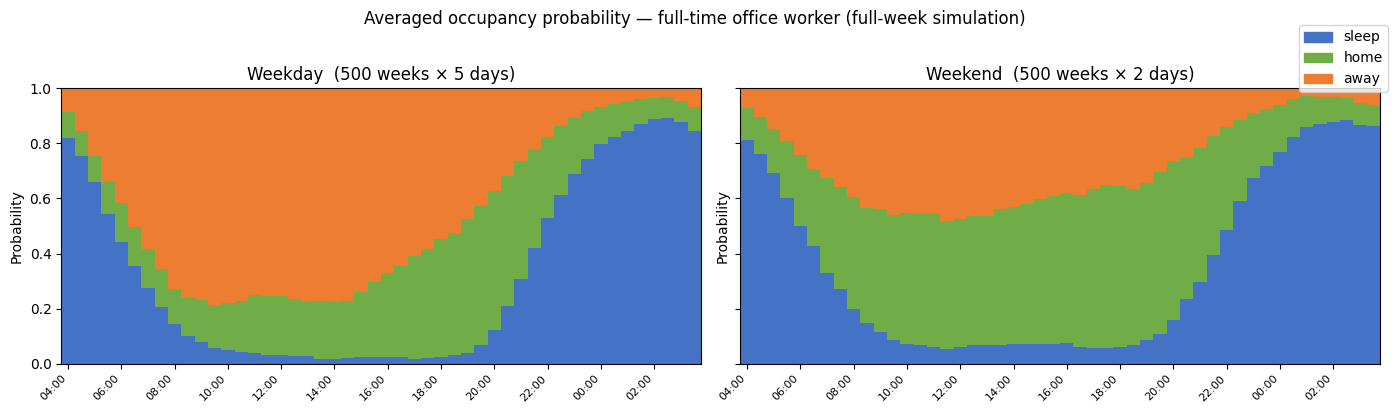


               sleep      home      away
   weekday     0.323     0.225     0.452
   weekend     0.347     0.375     0.277


In [16]:
# ── Multi-run averaged occupancy curves (full-week simulation) ────────────────
N_RUNS  = 500
N_BINS  = 48
states_list = ['sleep', 'home', 'away']

week_days = [
    ('Mon', 'weekday'), ('Tue', 'weekday'), ('Wed', 'weekday'),
    ('Thu', 'weekday'), ('Fri', 'weekday'),
    ('Sat', 'weekend'), ('Sun', 'weekend'),
]

def day_to_bin_series(schedule, n_bins=N_BINS):
    bins = np.empty(n_bins, dtype=object)
    for ep in schedule:
        b_start = int(ep['t_start'] // BIN_MIN)
        b_end   = int(np.ceil(ep['t_end'] / BIN_MIN))
        for b in range(max(0, b_start), min(n_bins, b_end)):
            bins[b] = ep['state']
    return bins

counts = {
    'weekday': {s: np.zeros(N_BINS) for s in states_list},
    'weekend': {s: np.zeros(N_BINS) for s in states_list},
}
day_counts = {'weekday': 0, 'weekend': 0}

np.random.seed(42)
for _ in range(N_RUNS):
    carry_state, carry_dur = None, 0
    for _, daytype in week_days:
        pi0 = pi0_weekday if daytype == 'weekday' else pi0_weekend
        sched, carry_state, carry_dur = simulate_day(daytype, pi0, carry_state, carry_dur)
        bins = day_to_bin_series(sched)
        for b, s in enumerate(bins):
            if s in counts[daytype]:
                counts[daytype][s][b] += 1
        day_counts[daytype] += 1

# Normalise by number of days simulated (not runs), so weekday=5×N_RUNS, weekend=2×N_RUNS
probs = {
    dt: {s: counts[dt][s] / day_counts[dt] for s in states_list}
    for dt in ('weekday', 'weekend')
}

# ── Plot ──────────────────────────────────────────────────────────────────────
bin_labels = [f"{(4 + b * BIN_MIN // 60) % 24:02d}:{(b * BIN_MIN) % 60:02d}" for b in range(N_BINS)]
tick_bins  = list(range(0, N_BINS, 4))
STATE_COLORS = {'sleep': '#4472C4', 'home': '#70AD47', 'away': '#ED7D31'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, dt in zip(axes, ('weekday', 'weekend')):
    bottom = np.zeros(N_BINS)
    for s in states_list:
        p = probs[dt][s]
        ax.bar(range(N_BINS), p, bottom=bottom, color=STATE_COLORS[s],
               label=s, width=1.0, edgecolor='none')
        bottom += p
    n_days = day_counts[dt] 
    ax.set_title(f'{dt.capitalize()}  ({N_RUNS} weeks × {n_days // N_RUNS} days)')
    ax.set_xticks(tick_bins)
    ax.set_xticklabels([bin_labels[b] for b in tick_bins], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.set_xlim(-0.5, N_BINS - 0.5)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=STATE_COLORS[s], label=s) for s in states_list],
           loc='upper right', bbox_to_anchor=(1.0, 1.0))
fig.suptitle('Averaged occupancy probability — full-time office worker (full-week simulation)', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n{'':>10}  {'sleep':>8}  {'home':>8}  {'away':>8}")
for dt in ('weekday', 'weekend'):
    row = {s: probs[dt][s].mean() for s in states_list}
    print(f"{dt:>10}  {row['sleep']:>8.3f}  {row['home']:>8.3f}  {row['away']:>8.3f}")


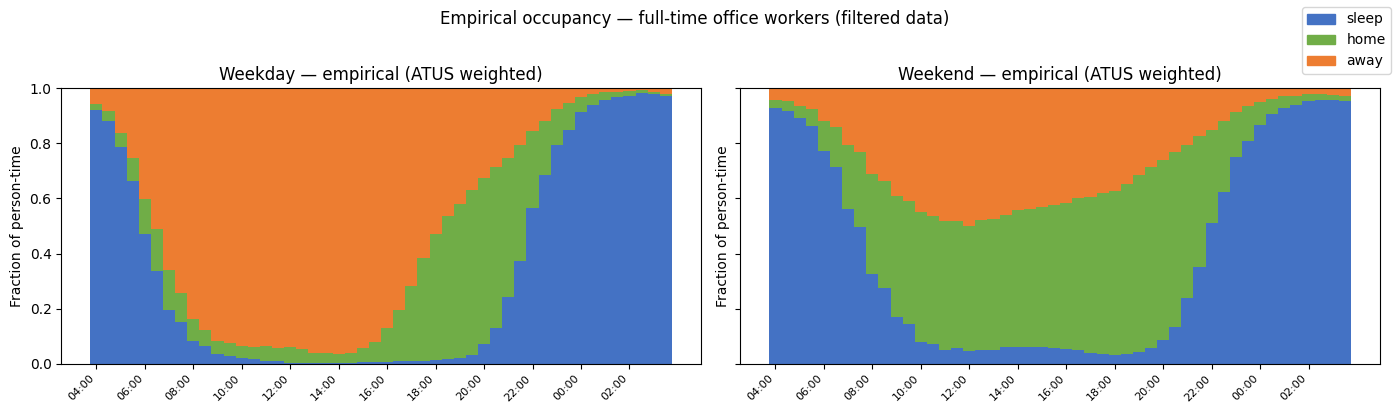

In [17]:
# ── Empirical weighted state distribution over time (weekday vs weekend) ──────
# For each 30-min bin, compute weighted fraction of person-time in each state.
# Each activity is credited to every bin it overlaps, proportional to overlap duration.

N_BINS = 48
records = []

t_entry = df['t_entry'].values
t_exit  = (df['t_entry'] + df['TUACTDUR']).values   # same as t_exit computed earlier
weight  = df['TUFINLWGT'].values
state   = df['state'].values
daytype = df['daytype'].values

for b in range(N_BINS):
    b_start = b * BIN_MIN
    b_end   = (b + 1) * BIN_MIN
    overlap = np.minimum(t_exit, b_end) - np.maximum(t_entry, b_start)
    mask = overlap > 0
    for dt in ('weekday', 'weekend'):
        dm = mask & (daytype == dt)
        for s in ('sleep', 'home', 'away'):
            sm = dm & (state == s)
            records.append({'bin': b, 'daytype': dt, 'state': s,
                            'w': (weight[sm] * overlap[sm]).sum()})

emp = pd.DataFrame(records)
emp['pct'] = emp['w'] / emp.groupby(['daytype', 'bin'])['w'].transform('sum')

# ── Plot ──────────────────────────────────────────────────────────────────────
bin_labels = [f"{(4 + b * BIN_MIN // 60) % 24:02d}:{(b * BIN_MIN) % 60:02d}" for b in range(N_BINS)]
tick_bins  = list(range(0, N_BINS, 4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, dt in zip(axes, ('weekday', 'weekend')):
    sub = emp[emp['daytype'] == dt]
    bottom = np.zeros(N_BINS)
    for s in ('sleep', 'home', 'away'):
        p = sub[sub['state'] == s].set_index('bin')['pct'].reindex(range(N_BINS), fill_value=0).values
        ax.bar(range(N_BINS), p, bottom=bottom, color=STATE_COLORS[s], label=s, width=1.0, edgecolor='none')
        bottom += p
    ax.set_title(f'{dt.capitalize()} — empirical (ATUS weighted)')
    ax.set_xticks(tick_bins)
    ax.set_xticklabels([bin_labels[b] for b in tick_bins], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Fraction of person-time')
    ax.set_ylim(0, 1)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=STATE_COLORS[s], label=s) for s in ('sleep','home','away')],
           loc='upper right')
fig.suptitle('Empirical occupancy — full-time office workers (filtered data)', y=1.02)
plt.tight_layout()
plt.show()


n=539  median=535 min  mean=415 min  p95=945 min  max=1140 min

KS statistic (lower = better fit):
  log-normal : 0.2450   mu=5.21  sigma=1.64  => mean=707 min
  Weibull    : 0.2439   k=0.79  scale=370
  Gamma      : 0.2395   a=0.68  scale=613


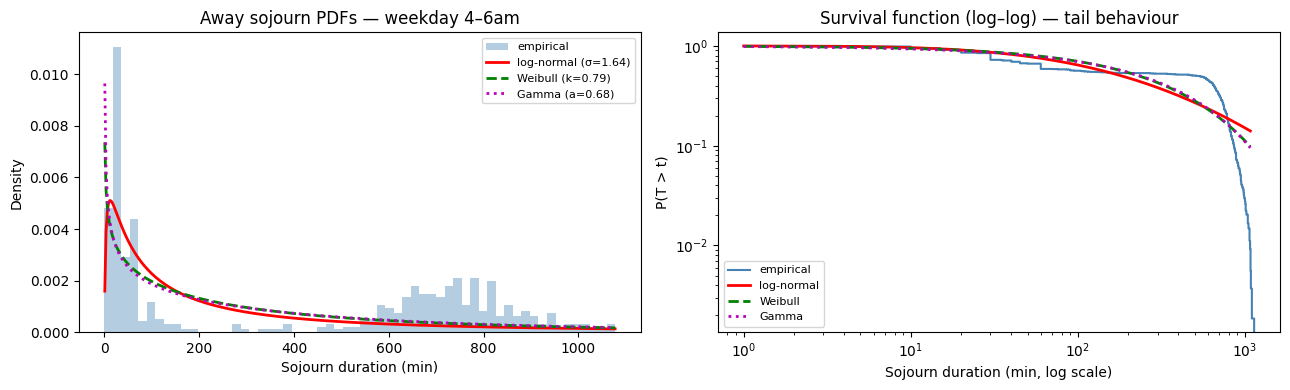

In [18]:
# ── Diagnose: away sojourn distribution at early-morning bins (weekday) ───────
# Check whether log-normal is a good fit vs Weibull / gamma
from scipy.stats import lognorm, weibull_min, gamma as gamma_dist, kstest
from scipy.optimize import curve_fit

EARLY_BINS = [0, 1, 2, 3]   # 4am–6am (30-min bins)
TARGET_STATE   = 'away'
TARGET_DAYTYPE = 'weekday'

subset = sojourns[
    (sojourns['daytype'] == TARGET_DAYTYPE) &
    (sojourns['state']   == TARGET_STATE)   &
    (sojourns['t_entry_bin'].isin(EARLY_BINS))
]['duration_min'].values

print(f"n={len(subset)}  median={np.median(subset):.0f} min  mean={subset.mean():.0f} min  "
      f"p95={np.percentile(subset,95):.0f} min  max={subset.max():.0f} min")

# ── Fit three distributions ───────────────────────────────────────────────────
w = sojourns[
    (sojourns['daytype'] == TARGET_DAYTYPE) &
    (sojourns['state']   == TARGET_STATE)   &
    (sojourns['t_entry_bin'].isin(EARLY_BINS))
]['TUFINLWGT'].values
w = w / w.sum()   # normalise weights for fitting

x = subset.clip(1)   # avoid log(0)

# Log-normal: fit via weighted mean/std of log(x)
log_x = np.log(x)
mu_ln  = np.average(log_x, weights=w)
sig_ln = np.sqrt(np.average((log_x - mu_ln)**2, weights=w))

# Weibull & Gamma: unweighted MLE (scipy)
wbl_c, _, wbl_scale = weibull_min.fit(x, floc=0)
gam_a, _, gam_scale = gamma_dist.fit(x,  floc=0)

# KS tests (unweighted, indicative)
ks_ln  = kstest(x, lambda v: lognorm.cdf(v, s=sig_ln, scale=np.exp(mu_ln)))[0]
ks_wbl = kstest(x, lambda v: weibull_min.cdf(v, wbl_c, scale=wbl_scale))[0]
ks_gam = kstest(x, lambda v: gamma_dist.cdf(v,  gam_a, scale=gam_scale))[0]

print(f"\nKS statistic (lower = better fit):")
print(f"  log-normal : {ks_ln:.4f}   mu={mu_ln:.2f}  sigma={sig_ln:.2f}  => mean={np.exp(mu_ln + sig_ln**2/2):.0f} min")
print(f"  Weibull    : {ks_wbl:.4f}   k={wbl_c:.2f}  scale={wbl_scale:.0f}")
print(f"  Gamma      : {ks_gam:.4f}   a={gam_a:.2f}  scale={gam_scale:.0f}")

# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_grid = np.linspace(1, np.percentile(x, 99), 400)

# PDF overlay
ax = axes[0]
ax.hist(x, bins=60, density=True, range=(0, np.percentile(x, 99)),
        color='steelblue', alpha=0.4, label='empirical')
ax.plot(x_grid, lognorm.pdf(x_grid, s=sig_ln, scale=np.exp(mu_ln)),
        'r-',  lw=2, label=f'log-normal (σ={sig_ln:.2f})')
ax.plot(x_grid, weibull_min.pdf(x_grid, wbl_c, scale=wbl_scale),
        'g--', lw=2, label=f'Weibull (k={wbl_c:.2f})')
ax.plot(x_grid, gamma_dist.pdf(x_grid, gam_a, scale=gam_scale),
        'm:',  lw=2, label=f'Gamma (a={gam_a:.2f})')
ax.set_xlabel('Sojourn duration (min)')
ax.set_ylabel('Density')
ax.set_title(f'Away sojourn PDFs — weekday 4–6am')
ax.legend(fontsize=8)

# Survival (CCDF) on log-x scale — highlights tail behaviour
ax = axes[1]
xs_sorted = np.sort(x)
ccdf = 1 - np.arange(1, len(xs_sorted)+1) / len(xs_sorted)
ax.step(xs_sorted, ccdf, color='steelblue', lw=1.5, label='empirical')
ax.plot(x_grid, 1 - lognorm.cdf(x_grid, s=sig_ln, scale=np.exp(mu_ln)),
        'r-',  lw=2, label='log-normal')
ax.plot(x_grid, 1 - weibull_min.cdf(x_grid, wbl_c, scale=wbl_scale),
        'g--', lw=2, label='Weibull')
ax.plot(x_grid, 1 - gamma_dist.cdf(x_grid, gam_a, scale=gam_scale),
        'm:',  lw=2, label='Gamma')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Sojourn duration (min, log scale)')
ax.set_ylabel('P(T > t)')
ax.set_title('Survival function (log–log) — tail behaviour')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
